# 1. Data loading

### 1.1 Importing modules

In [142]:
# import all modules
import pandas as pd
import geopandas as gpd
import requests
import matplotlib.pyplot as plt
!pip install contextily
import contextily as cx

In [143]:
area_url='https://firms.modaps.eosdis.nasa.gov/api/area/csv/38064bff4711161d2878baf2b432ef5f/VIIRS_NOAA20_NRT/world/3'

response=requests.get(area_url)
# print(response.text) #here I saw that its already plain text and not json to parse, no .json() to unpack required

#Check
if response.status_code==200:
      print("Request worked")
else:
      print("Request did not work")

# Create dataframe
df_area = pd.read_csv(area_url)
df_area

Request worked


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
0,12.63854,29.10139,314.32,0.44,0.46,2026-05-13,1,N20,VIIRS,n,2.0NRT,292.16,2.02,N
1,12.64421,29.54539,305.49,0.47,0.48,2026-05-13,1,N20,VIIRS,n,2.0NRT,291.90,1.48,N
2,12.75791,29.32753,304.44,0.45,0.47,2026-05-13,1,N20,VIIRS,n,2.0NRT,293.36,1.05,N
3,12.75868,29.32342,313.05,0.45,0.47,2026-05-13,1,N20,VIIRS,n,2.0NRT,293.76,1.05,N
4,12.75906,29.32852,312.53,0.45,0.47,2026-05-13,1,N20,VIIRS,n,2.0NRT,293.79,1.68,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77257,45.22788,-123.16752,299.68,0.34,0.56,2026-05-15,1106,N20,VIIRS,n,2.0NRT,277.44,1.39,N
77258,45.23268,-123.16479,317.21,0.34,0.56,2026-05-15,1106,N20,VIIRS,n,2.0NRT,276.98,1.39,N
77259,37.95090,-122.39953,299.16,0.60,0.70,2026-05-15,1108,N20,VIIRS,n,2.0NRT,287.39,1.19,N
77260,37.95763,-121.15919,301.48,0.69,0.74,2026-05-15,1108,N20,VIIRS,n,2.0NRT,282.70,1.45,N


# 2. Data cleaning

In [147]:
wildfire_gdf=gpd.GeoDataFrame(df_area, geometry=gpd.points_from_xy(df_area["longitude"], df_area["latitude"]), crs=(4326))
wildfire_gdf.head(3)
print(wildfire_gdf.describe())
print(wildfire_gdf.crs)

           latitude     longitude    bright_ti4          scan         track  \
count  77262.000000  77262.000000  77262.000000  77262.000000  77262.000000   
mean      10.146927     32.578419    333.550137      0.463020      0.493611   
std       24.293375     76.814948     16.691565      0.088863      0.115367   
min      -77.526080   -155.294040    207.930000      0.320000      0.360000   
25%      -11.541640     -9.859468    329.080000      0.400000      0.390000   
50%       11.107595     33.056230    335.850000      0.440000      0.460000   
75%       30.315907    105.973052    343.180000      0.520000      0.580000   
max       70.692120    177.153350    367.000000      0.800000      0.780000   

           acq_time    bright_ti5           frp  
count  77262.000000  77262.000000  77262.000000  
mean    1157.454441    296.609770      8.030981  
std      581.267980     10.019301     13.239820  
min        1.000000    237.930000      0.000000  
25%      712.000000    290.980000     

# 3. Spatial analysis

In [ ]:
# Spatial analysis part: Load in world-cities (worldcities_csv), select only where population large, buffer around them, look if intersection with filter


In [154]:
#Cut off extremes, differentiate between frp_raw for analysis, and frp_vis for visualization

wildfire_gdf = wildfire_gdf[wildfire_gdf["frp"] > 30].copy()

wildfire_gdf["frp_raw"] = wildfire_gdf["frp"]

upper = wildfire_gdf["frp"].quantile(0.99)

wildfire_gdf["frp_vis"] = wildfire_gdf["frp"].clip(upper=upper)

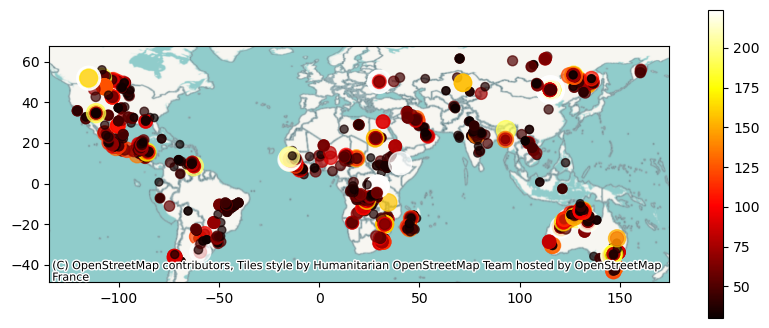

In [155]:
#With normalization
import contextily as cx

fig, ax= plt.subplots(figsize=(10,4))

wildfire_gdf.plot(ax=ax, column="frp_vis", cmap="hot", markersize="frp_raw", alpha=0.7, legend=True)

cx.add_basemap(
    ax,
    crs="EPSG:4326"
)


<function matplotlib.pyplot.show(close=None, block=None)>

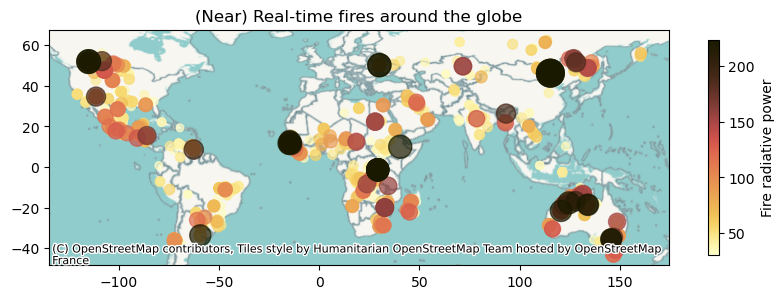

In [156]:
import cmcrameri.cm as cmc
#cmc lipari or OrRd or lajolla

wildfire_gdf_sorted=wildfire_gdf.sort_values("frp_vis")

fig, ax= plt.subplots(figsize=(10,4))

legend_options= legend_options = { "label": "Fire radiative power", "orientation": "vertical", "shrink": 0.7}
wildfire_gdf_sorted.plot(ax=ax, column="frp_vis", cmap="cmc.lajolla_r", markersize="frp", alpha=0.7, legend=True, legend_kwds=legend_options)
cx.add_basemap(ax=ax, crs=4326)
plt.title("(Near) Real-time fires around the globe")
plt.show

In [158]:
#Introduce uncertainty with transparency
wildfire_gdf["confidence"].unique()

import numpy as np

wildfire_gdf["alpha"] = np.select(
    [
        wildfire_gdf["confidence"] == "h",
        wildfire_gdf["confidence"] == "n",
        wildfire_gdf["confidence"] == "l",
    ],
    [
        1.0,
        0.7,
        0.4
    ],
    default=0.5
)

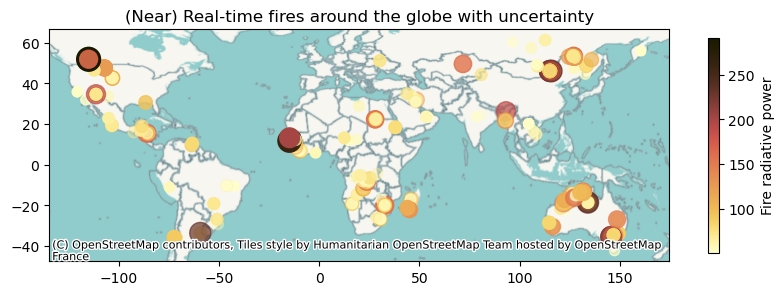

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
import cmcrameri.cm as cmc

# -------------------------
# 1. Filter FRP
# -------------------------
wildfire_gdf = wildfire_gdf[wildfire_gdf["frp"] > 50].copy()

# -------------------------
# 2. Map confidence → alpha
# -------------------------
wildfire_gdf["alpha"] = np.select(
    [
        wildfire_gdf["confidence"] == "h",
        wildfire_gdf["confidence"] == "n",
        wildfire_gdf["confidence"] == "l",
    ],
    [
        1.0,
        0.7,
        0.4
    ],
    default=0.5
)

# -------------------------
# 3. Scale FRP for marker size
# -------------------------
wildfire_gdf["size"] = wildfire_gdf["frp"]

# -------------------------
# 4. Plot
# -------------------------
fig, ax = plt.subplots(figsize=(10, 4))

wildfire_gdf.plot(
    ax=ax,
    column="frp",
    cmap=cmc.lajolla_r,
    markersize=wildfire_gdf["size"],
    alpha=wildfire_gdf["alpha"],   # 👈 uncertainty here
    legend=True,
    legend_kwds={
        "label": "Fire radiative power",
        "orientation": "vertical",
        "shrink": 0.7
    }
)

# Basemap (correct CRS assumed EPSG:4326 -> 3857)
cx.add_basemap(ax=ax, crs=wildfire_gdf.crs)

plt.title("(Near) Real-time fires around the globe with uncertainty")
plt.show()

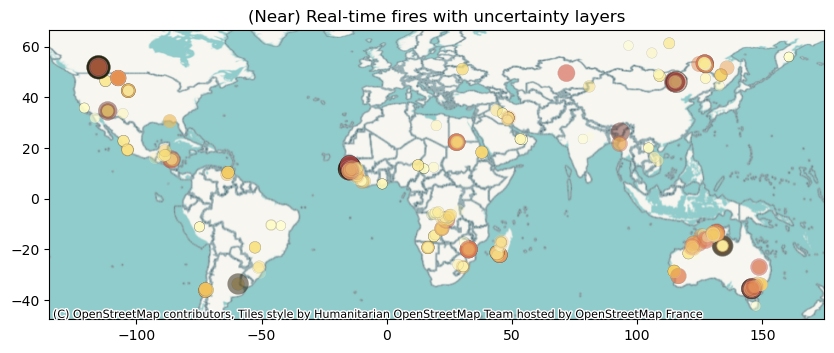

In [35]:
import matplotlib.pyplot as plt
import contextily as cx
import cmcrameri.cm as cmc

# Filter
wildfire_gdf = wildfire_gdf[wildfire_gdf["frp"] > 50].copy()

# Size scaling
wildfire_gdf["size"] = wildfire_gdf["frp"]

# Split datasets
high = wildfire_gdf[wildfire_gdf["confidence"] == "h"]
nominal = wildfire_gdf[wildfire_gdf["confidence"] == "n"]
low = wildfire_gdf[wildfire_gdf["confidence"] == "l"]

fig, ax = plt.subplots(figsize=(10, 5))

# -------------------
# High confidence (solid)
# -------------------
high.plot(
    ax=ax,
    column="frp",
    cmap=cmc.lajolla_r,
    markersize=high["size"],
    alpha=0.9,
    legend=False,
    edgecolor="black",
    linewidth=0.2
)

# -------------------
# Nominal confidence (dashed feel)
# -------------------
nominal.plot(
    ax=ax,
    column="frp",
    cmap=cmc.lajolla_r,
    markersize=nominal["size"],
    alpha=0.5,
    legend=False,
    edgecolor="gray",
    linewidth=0.2
)

# -------------------
# Low confidence (faint + gray outline)
# -------------------
low.plot(
    ax=ax,
    column="frp",
    cmap=cmc.lajolla_r,
    markersize=low["size"],
    alpha=0.25,
    legend=False,
    edgecolor="white",
    linewidth=0.3
)

# Basemap
cx.add_basemap(ax=ax, crs=wildfire_gdf.crs)

plt.title("(Near) Real-time fires with uncertainty layers")
plt.show()

In [ ]:
# Next step: Do proper map, with normalizing, making classification, handling missing values and so on using this code and practicals VL8
# import geopandas as gpd
# import matplotlib.pyplot as plt
# import cmcrameri.cm as cmc
# import numpy as np

# # 1. Setup
# fig, ax = plt.subplots(figsize=(12, 10))

# # 4. Legend options
# legend_options = {
#     "label": "Ratio: Women per 100 Men",
#     "orientation": "vertical",
#     "shrink": 0.7
# }

# # 6. Missing data options
# missing_styling = {
#     "color": "#EEEEEE",
#     "label": "No Data"
# }

# # 2, 3, 5. Plot the choropleth
# nuts.plot(
#     ax=ax,
#     column="women_per100men",
#     cmap=cmc.vik, 
#     vmin=vmin,
#     vmax=vmax,
#     legend=True,
#     legend_kwds=legend_options,
#     missing_kwds=missing_styling,
#     edgecolor="black",
#     linewidth=0.1
# )

# # 7. Formatting
# ax.set_title("Gender Ratio Across European Regions", fontsize=16)
# ax.axis("off")
ax.grid(True)

# plt.show()

# 4. Visualization

In [159]:
# Best interactive map until now

import numpy as np
import folium
import matplotlib.cm as cm
import matplotlib.colors as colors

# SORT (big fires last → on top)
wildfire_filtered = wildfire_filtered.sort_values("frp_vis", ascending=True)

# Color scale based on VISUAL values
vmin = wildfire_filtered["frp_vis"].min()
vmax = wildfire_filtered["frp_vis"].max()

norm = colors.Normalize(vmin=vmin, vmax=vmax)
cmap = cm.get_cmap("YlOrRd")

# Map (dark background)
m = folium.Map(
    location=[20, 0],
    zoom_start=2,
    tiles="CartoDB dark_matter",
    #control_scale=True
)


for _, row in wildfire_filtered.iterrows():

    frp = row["frp_vis"]

    # SIZE (direct scaling, no sqrt/log)
    radius = max(frp / 10, 2)

    # COLOR (based on same variable)
    color = colors.to_hex(cmap(norm(frp)))

    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.75,
        popup=f"FRP [MW]: {row['frp']:.1f},  Date: {row['acq_date']}"
    ).add_to(m)

m.save("wildfire2.html")

C:\Users\Javier Feller\AppData\Local\Temp\ipykernel_39568\3001905583.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlOrRd")


In [164]:
# Prepare Interactive map with recentness of events

# convert aqc_date and aqc_time to acq_datetime as datetime object
wildfire_gdf['acq_datetime'] = pd.to_datetime(wildfire_gdf['acq_date'] + ' ' + wildfire_gdf['acq_time'].astype(str).str.zfill(4), format='%Y-%m-%d %H%M')

# find maximum time from our dataset since we are pretending current date time is July 12 2023, 19:50(7:50pm) GMT.
# if the data were recent, we would set 
dt_max = pd.Timestamp.now();

# create our subsets for 4 color classes

# less than or equal to 1 hour; gdf1 <= 1hour
wildfire_gdf_12h = wildfire_gdf[wildfire_gdf['acq_datetime'] >= (dt_max - pd.Timedelta(hours=12))]

# greater than 1 hour but less than or equal to 24 hours; gdf2 > 1 hour and gdf2 <= 12 hours
wildfire_gdf_24h = wildfire_gdf[(wildfire_gdf['acq_datetime'] >= (dt_max - pd.Timedelta(hours=24))) & (wildfire_gdf['acq_datetime'] < (dt_max - pd.Timedelta(hours=12)))]

# greater than 1 hour but less than or equal to 24 hours; gdf2 > 1 hour and gdf2 <= 12 hours
wildfire_gdf_48h = wildfire_gdf[(wildfire_gdf['acq_datetime'] >= (dt_max - pd.Timedelta(hours=48))) & (wildfire_gdf['acq_datetime'] < (dt_max - pd.Timedelta(hours=24)))]

# greater than 24 hours; gdf4 > 12 hours
wildfire_gdf_more48h = wildfire_gdf[wildfire_gdf['acq_datetime'] < (dt_max - pd.Timedelta(hours=48))]

# now let's make sure the sizes are correct. They should all add up to 14045
# print ('Sizes %i, %i, %i, %i from total of %i' % (wildfire_gdf_1h.count()[0],wildfire_gdf_12h.count()[0],wildfire_gdf_24h.count()[0],wildfire_gdf_more24h.count()[0], gdf.count()[0]))

C:\Users\Javier Feller\AppData\Local\Temp\ipykernel_39568\1618935137.py:36: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  wildfire_12h.plot(


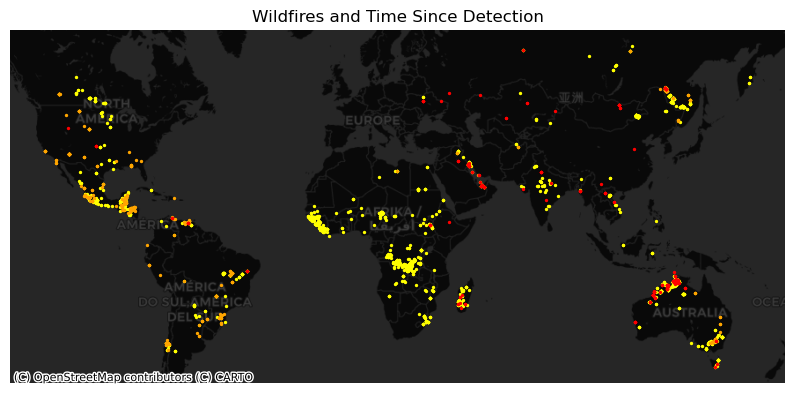

In [167]:
import matplotlib.pyplot as plt
import contextily as cx

# Reproject to Web Mercator
wildfire_more48h = wildfire_gdf_more24h.to_crs(epsg=3857)
wildfire_48h = wildfire_gdf_24h.to_crs(epsg=3857)
wildfire_24h = wildfire_gdf_12h.to_crs(epsg=3857)
wildfire_12h = wildfire_gdf_5h.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))

# -------------------------
# Fire layers (old → new)
# -------------------------
wildfire_more48h.plot(
    ax=ax,
    color="yellow",
    markersize=2,
    alpha=1
)

wildfire_48h.plot(
    ax=ax,
    color="orange",
    markersize=2,
    alpha=1
)

wildfire_24h.plot(
    ax=ax,
    color="red",
    markersize=2,
    alpha=1
)

wildfire_12h.plot(
    ax=ax,
    color="darkred",
    markersize=2,
    alpha=1
)

# -------------------------
# Basemap
# -------------------------
cx.add_basemap(
    ax=ax,
    source=cx.providers.CartoDB.DarkMatter
)

# -------------------------
# Styling
# -------------------------
ax.set_title("Wildfires and Time Since Detection")
ax.set_axis_off()

plt.show()

In [170]:
import folium

# --------------------------------------------
# MAP
# --------------------------------------------
m = folium.Map(
    location=[20, 0],
    zoom_start=2,
    tiles="CartoDB dark_matter",
    prefer_canvas=True
)

# ============================================
# FUNCTION
# ============================================

def add_fire_layer(gdf, color, opacity):

    # sort small -> large
    gdf = gdf.sort_values("frp_vis", ascending=True)

    for _, row in gdf.iterrows():

        # FRP = size
        radius = max(row["frp_vis"] / 10, 2)

        popup_text = (
            f"<b>FRP:</b> {row['frp']:.1f} MW<br>"
            f"<b>Date:</b> {row['acq_datetime']}<br>"
            f"<b>Confidence:</b> {row['confidence']}"
        )

        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=radius,
            color=color,
            weight=0,
            fill=True,
            fill_color=color,
            fill_opacity=opacity,
            popup=folium.Popup(popup_text, max_width=250)
        ).add_to(m)

# ============================================
# TIME CLASSES
# ============================================

# # older fires
add_fire_layer(
    wildfire_gdf_more48h,
    color="yellow",
    opacity=1
)

# medium recent fires
add_fire_layer(
    wildfire_gdf_48h,
    color="orange",
    opacity=1
)

# new fires
add_fire_layer(
    wildfire_gdf_24h,
    color="red",
    opacity=1
)

# newest fires
add_fire_layer(
    wildfire_gdf_12h,
    color="darkred",
    opacity=1
)

# ============================================
# SAVE
# ============================================

m.save("wildfire_temporal_map3.html")

In [171]:
import folium

# --------------------------------------------
# MAP
# --------------------------------------------
m = folium.Map(
    location=[20, 0],
    zoom_start=2,
    tiles="CartoDB dark_matter",
    prefer_canvas=True
)

# ============================================
# FUNCTION
# ============================================

def add_fire_layer(gdf, color, opacity):

    # sort small -> large
    gdf = gdf.sort_values("frp_vis", ascending=True)

    for _, row in gdf.iterrows():

        # FRP = size
        radius = max(row["frp_vis"] / 10, 2)

        popup_text = (
            f"<b>FRP:</b> {row['frp']:.1f} MW<br>"
            f"<b>Date:</b> {row['acq_datetime']}<br>"
            f"<b>Confidence:</b> {row['confidence']}"
        )

        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=radius,
            color=color,
            weight=0,
            fill=True,
            fill_color=color,
            fill_opacity=opacity,
            popup=folium.Popup(popup_text, max_width=250)
        ).add_to(m)

# ============================================
# TIME CLASSES
# ============================================

# # older fires
add_fire_layer(
    wildfire_gdf_more48h,
    color="yellow",
    opacity=1
)

# medium recent fires
add_fire_layer(
    wildfire_gdf_48h,
    color="orange",
    opacity=1
)

# new fires
add_fire_layer(
    wildfire_gdf_24h,
    color="red",
    opacity=1
)

# newest fires
add_fire_layer(
    wildfire_gdf_12h,
    color="darkred",
    opacity=1
)

# ============================================
# SAVE
# ============================================



# ============================================
# LEGEND
# ============================================

legend_html = """
<div style="
    position: fixed;
    bottom: 40px;
    left: 40px;
    width: 180px;
    height: 150px;
    background-color: black;
    border:2px solid grey;
    z-index:9999;
    font-size:14px;
    color:white;
    padding: 10px;
    opacity: 0.85;
">

<b>Wildfire Detection Time</b><br><br>

<i style="background:yellow;
width:12px;
height:12px;
float:left;
margin-right:8px;
opacity:1;"></i>
Older than 48h<br><br>

<i style="background:orange;
width:12px;
height:12px;
float:left;
margin-right:8px;
opacity:1;"></i>
24–48h<br><br>

<i style="background:red;
width:12px;
height:12px;
float:left;
margin-right:8px;
opacity:1;"></i>
12–24h<br><br>

<i style="background:darkred;
width:12px;
height:12px;
float:left;
margin-right:8px;
opacity:1;"></i>
Last 12h

</div>
"""

m.get_root().html.add_child(folium.Element(legend_html))

m.save("wildfire_temporal_map3.html")